# **MACHINE LEARNING: ASSIGNMENT 02**

### **0. IMPORT REQUIRED LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, silhouette_score,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

import warnings
warnings.filterwarnings("ignore")

### **1. IMPORT DATA AND EXPLORATORY DATA ANALYSIS (EDA)**

##### **1.1 Dataset loading**

In [2]:
# Load dataset
df = pd.read_csv('A2_Customer_Behavior_Analytics.csv')
df.shape

(600, 10)

In [3]:
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Order_Frequency,Avg_Order_Value,Delivery_Distance,Channel
0,1701,3297,4632,1203,2134,40,12.2,3368,23.6,1
1,1262,2456,2704,329,687,947,10.9,1225,14.4,1
2,2504,1819,1968,1691,999,669,14.9,803,10.3,1
3,5033,662,2993,1197,1290,1142,15.0,2200,8.3,1
4,3852,1509,1127,2299,-77,240,13.7,890,7.7,0


##### **1.2 Quality inspection**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fresh              600 non-null    int64  
 1   Milk               600 non-null    int64  
 2   Grocery            600 non-null    int64  
 3   Frozen             600 non-null    int64  
 4   Detergents_Paper   600 non-null    int64  
 5   Delicatessen       600 non-null    int64  
 6   Order_Frequency    600 non-null    float64
 7   Avg_Order_Value    600 non-null    int64  
 8   Delivery_Distance  600 non-null    float64
 9   Channel            600 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 47.0 KB


In [5]:
# Check for missing values
df.isnull().sum()

Fresh                0
Milk                 0
Grocery              0
Frozen               0
Detergents_Paper     0
Delicatessen         0
Order_Frequency      0
Avg_Order_Value      0
Delivery_Distance    0
Channel              0
dtype: int64

In [6]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

#### **1.3 Target variable distribution**

In [7]:
# Target variable distribution 
df['Channel'].value_counts()

Channel
0    330
1    270
Name: count, dtype: int64

In [8]:
# Target variable distribution %
df['Channel'].value_counts(normalize=True)

Channel
0    0.55
1    0.45
Name: proportion, dtype: float64

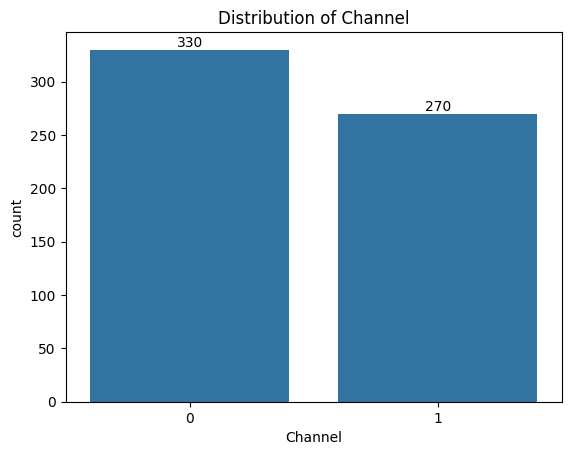

In [9]:
ax = sns.countplot(x="Channel", data=df)
plt.title("Distribution of Channel")

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### **1.4 Numeric variables distribution**

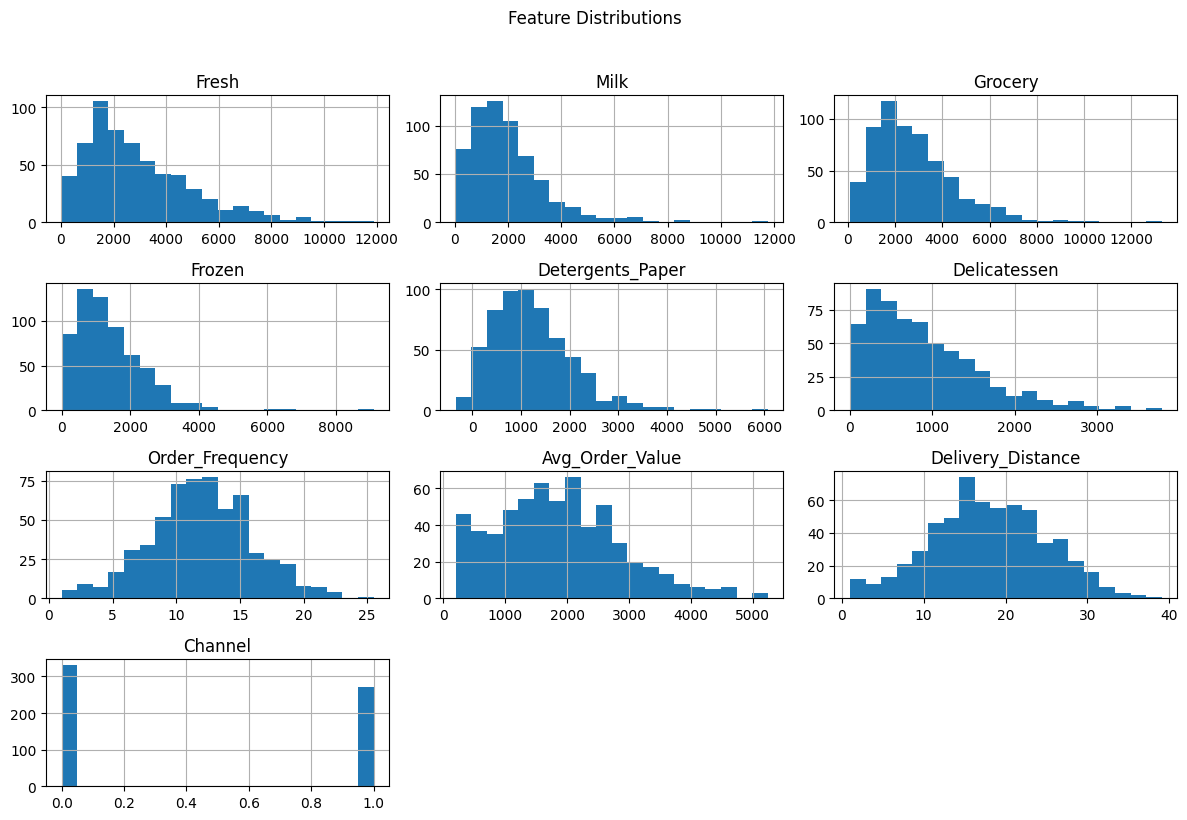

In [10]:
# Histograms for all numeric features
df.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout() # Para que no se encimen los títulos
plt.show()

#### **1.5 Correlation analysis**

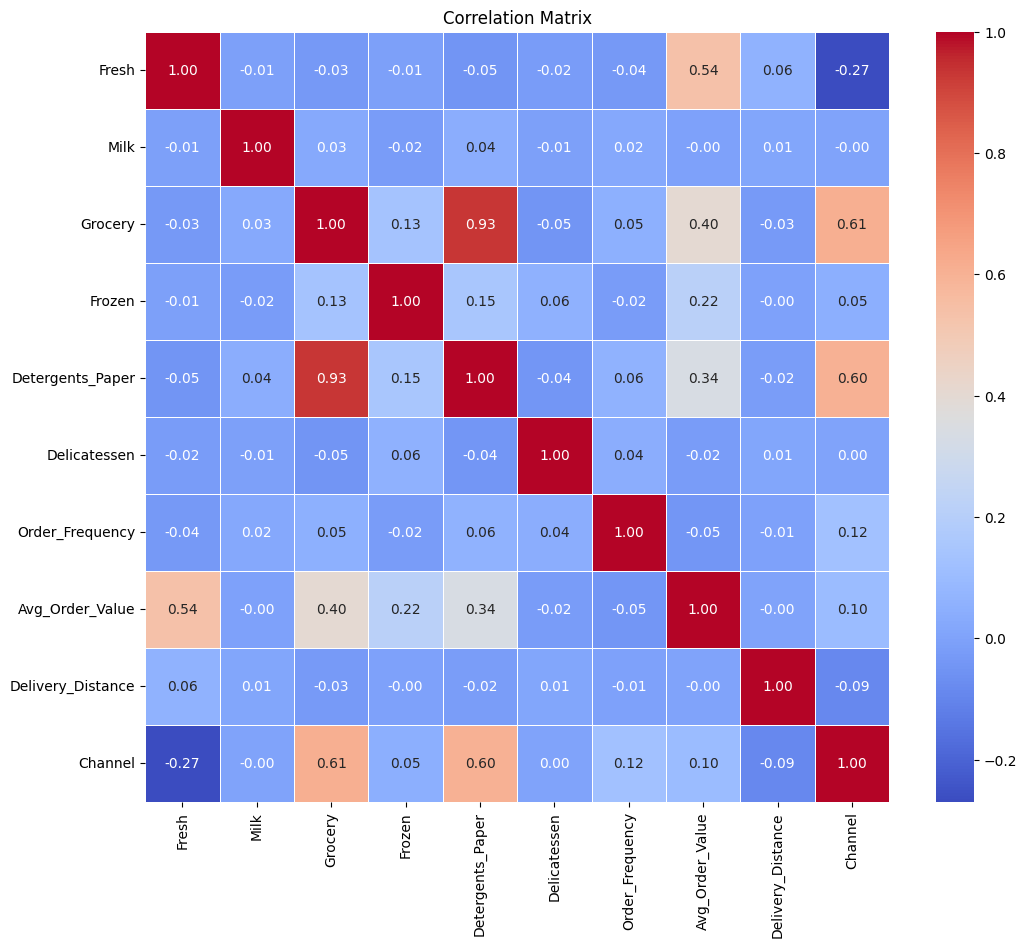

In [11]:
# Correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### **2. EXPERIMENTAL DESIGN AND CLASSIFICATION ANALYSIS**

This chapter defines a reproducible experimental protocol and evaluates one Ensemble model and one SVM model under the assignment constraints.

#### **2.1 Experimental design**

A stratified 70/30 train–test split and 5-fold stratified cross-validation are used to support fair model selection and robust generalization estimates.

In [12]:
# Separate features and target variable
target_col = "Channel"
high_correlation= "Grocery"
X = df.drop(columns=[target_col,high_correlation])
y = df[target_col]

# Fix random state for reproducibility
RANDOM_STATE = 42

# Split the dataset into training and testing sets 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

# 5-fold stratified cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Hyperparameter candidates (one per family, three values max)
rf_candidates = [100, 300, 600] # Random Forest: n_estimators
svm_candidates = [0.1, 1, 10] # SVM: C

#### **2.2 Random Forest Model Construction (RF)**

The Random Forest model is evaluated as the selected Ensemble approach, with controlled tuning of a single hyperparameter.

#### *2.2.1 Model building and cross-validation (RF)*

Cross-validation is applied on the training set to compare candidate configurations while avoiding test-set leakage.

In [13]:
# Computes fold-level F1-scores for a given model using stratified cross-validation on
# the training set
def cv_f1_scores_for_model(model, X_tr, y_tr, cv_obj):
    f1_scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(cv_obj.split(X_tr, y_tr), start=1):
        # The training fold is used to fit the model
        X_fold_tr = X_tr.iloc[tr_idx]
        y_fold_tr = y_tr.iloc[tr_idx]

        # The validation fold is used to evaluate generalization
        X_fold_val = X_tr.iloc[val_idx]
        y_fold_val = y_tr.iloc[val_idx]

        # The model is trained only on the fold training data
        model.fit(X_fold_tr, y_fold_tr)

        # Predictions are generated for the validation fold
        preds = model.predict(X_fold_val)

        # F1-score is computed to balance precision and recall
        f1 = f1_score(y_fold_val, preds)
        f1_scores.append(f1)

    return np.array(f1_scores)

In [14]:
# The model configuration is defined with the selected number of trees
rf_results = []

for n in rf_candidates:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Cross-validated F1-scores are computed on the training set
    scores = cv_f1_scores_for_model(rf, X_train, y_train, cv)
    
    # Mean and standard deviation summarize performance and stability
    rf_results.append({
        "Model": "Random Forest",
        "Setting": f"n_estimators={n}",
        "CV F1 (mean)": scores.mean(),
        "CV F1 (std)": scores.std(ddof=1)
    })

rf_results_df = pd.DataFrame(rf_results).sort_values("CV F1 (mean)", ascending=False).reset_index(drop=True)

#### *2.2.2 Best model training (RF)*

The best-performing configuration is refit on the full training set and then evaluated once on the held-out test set.

In [15]:
# Train the best Random Forest on the full training set and evaluate on the test set
best_rf_setting = rf_results_df.loc[0, "Setting"]
best_rf_n = int(best_rf_setting.split("=")[1])

best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_n),
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# The final model is trained on the full training set
best_rf.fit(X_train, y_train)

# Test predictions and probabilities are computed
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

# Test metrics are reported as required
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Compute confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)

# ROC curve coordinates
rf_auc = roc_auc_score(y_test, rf_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

#### **2.3 SVM Model Construction (RBF kernel)**

The RBF-kernel SVM is evaluated as the selected SVM approach, with standardization applied to address feature scale sensitivity.

#### *2.3.1 Model building and cross-validation (SVM)*

Feature standardization is fitted within each cross-validation fold to prevent information leakage and to ensure valid model selection.

In [16]:
# This function computes column-wise mean and standard deviation from a training dataset only
def fit_standardizer(X_df):
    mean_ = X_df.mean(axis=0)
    std_ = X_df.std(axis=0, ddof=0).replace(0, 1.0)  # Prevent division by zero
    return mean_, std_

# This function standardizes features using precomputed training statistics
def transform_standardizer(X_df, mean_, std_):
    return (X_df - mean_) / std_

In [17]:
# Cross-validated F1 for SVM with fold-specific scaling (prevents leakage)
def cv_f1_scores_for_svm(C_value, X_tr, y_tr, cv_obj):
    f1_scores = []
    for fold_idx, (tr_idx, val_idx) in enumerate(cv_obj.split(X_tr, y_tr), start=1):
        # The training fold is used to fit the model
        X_fold_tr = X_tr.iloc[tr_idx]
        y_fold_tr = y_tr.iloc[tr_idx]

        # The validation fold is used to evaluate generalization
        X_fold_val = X_tr.iloc[val_idx]
        y_fold_val = y_tr.iloc[val_idx]

        # The scaler is fitted on the fold training data only
        mu, sigma = fit_standardizer(X_fold_tr)

        # Both training and validation folds are transformed using training-only statistics
        X_fold_tr_scaled = transform_standardizer(X_fold_tr, mu, sigma)
        X_fold_val_scaled = transform_standardizer(X_fold_val, mu, sigma)

        # The SVM model is trained with a fixed kernel and the candidate C value
        svm = SVC(kernel="rbf", C=C_value)
        svm.fit(X_fold_tr_scaled, y_fold_tr)

        # Predictions are produced for the validation fold
        preds = svm.predict(X_fold_val_scaled)

        # F1-score is computed for fold-level performance
        f1 = f1_score(y_fold_val, preds)
        f1_scores.append(f1)

    return np.array(f1_scores)

In [18]:
# The model configuration is defined with the selected number of trees
svm_results = []

for C in svm_candidates:
    scores = cv_f1_scores_for_svm(C, X_train, y_train, cv)
    svm_results.append({
        "Model": "RBF SVM",
        "Setting": f"C={C}",
        "CV F1 (mean)": scores.mean(),
        "CV F1 (std)": scores.std(ddof=1)
    })

svm_results_df = pd.DataFrame(svm_results).sort_values("CV F1 (mean)", ascending=False).reset_index(drop=True)

#### *2.3.2 Best model training (SVM)*

The selected configuration is trained on standardized training data and evaluated on a standardized test set using training-only statistics.

In [19]:
# Train the best SVM on the full training set and evaluate on the test set
best_svm_setting = svm_results_df.loc[0, "Setting"]
best_svm_C = float(best_svm_setting.split("=")[1])

# The scaler is fitted on the full training set only
mu_train, sigma_train = fit_standardizer(X_train)

# Training and test sets are standardized using training-only statistics
X_train_scaled = transform_standardizer(X_train, mu_train, sigma_train)
X_test_scaled = transform_standardizer(X_test, mu_train, sigma_train)

# The final SVM model is trained using the selected C value
best_svm = SVC(kernel="rbf", C=best_svm_C)
best_svm.fit(X_train_scaled, y_train)

# Test predictions are generated
svm_pred = best_svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

# Compute confusion matrix
cm_svm = confusion_matrix(y_test, svm_pred)

# ROC curve coordinates are computed
svm_score = best_svm.decision_function(X_test_scaled)
svm_auc = roc_auc_score(y_test, svm_score)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_score)

#### **2.4 Summary of Results**

This section consolidates cross-validation outcomes and test-set performance for direct comparison between model families.

#### *2.4.1 Main metrics*

Test performance is reported using Accuracy, Precision, Recall, F1-score, and ROC-AUC to capture complementary aspects of classification quality.

In [20]:
display(rf_results_df.round(4))
display(svm_results_df.round(4))

,Model,Setting,CV F1 (mean),CV F1 (std)
0,Random Forest,n_estimators=600,0.7675,0.0863
1,Random Forest,n_estimators=300,0.7654,0.0835
2,Random Forest,n_estimators=100,0.7569,0.0817


,Model,Setting,CV F1 (mean),CV F1 (std)
0,RBF SVM,C=1,0.7414,0.0346
1,RBF SVM,C=10,0.7003,0.0580
2,RBF SVM,C=0.1,0.6298,0.0549


The results of the CV F1 (mean) and standard deviation CV F1(std) are compared to decide which is the Best Setting. 

In [21]:

results_parallel = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Best Setting": best_rf_setting,
        "CV F1 (mean)": rf_results_df.loc[0, "CV F1 (mean)"],
        "CV F1 (std)": rf_results_df.loc[0, "CV F1 (std)"],
        "Test Accuracy": rf_accuracy,
        "Test Precision": rf_precision,
        "Test Recall": rf_recall,
        "Test F1": rf_f1,
        "Test ROC-AUC": rf_auc
    },
    {
        "Model": "RBF SVM",
        "Best Setting": best_svm_setting,
        "CV F1 (mean)": svm_results_df.loc[0, "CV F1 (mean)"],
        "CV F1 (std)": svm_results_df.loc[0, "CV F1 (std)"],
        "Test Accuracy": svm_accuracy,
        "Test Precision": svm_precision,
        "Test Recall": svm_recall,
        "Test F1": svm_f1,
        "Test ROC-AUC": svm_auc
    }
])

display(results_parallel.round(4))

,Model,Best Setting,CV F1 (mean),CV F1 (std),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest,n_estimators=600,0.7675,0.0863,0.8111,0.7901,0.7901,0.7901,0.8823
1,RBF SVM,C=1,0.7414,0.0346,0.8056,0.8026,0.7531,0.7771,0.8813


#### *2.4.2 Confusion matrices*
Confusion matrices summarize error types to support an assessment of business-relevant trade-offs.

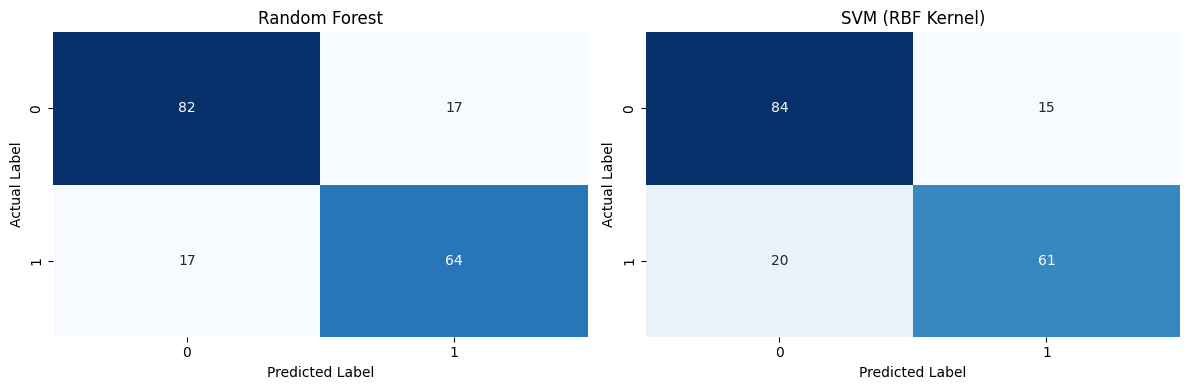

In [22]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random forest confusion matrix
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[0, 1],
    yticklabels=[0, 1],
    ax=axes[0]
)
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# SVM confusion matrix
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[0, 1],
    yticklabels=[0, 1],
    ax=axes[1]
)
axes[1].set_title("SVM (RBF Kernel)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

#### *2.4.3 ROC Curves*

ROC curves visualize the ranking performance of both models across decision thresholds on the test set.

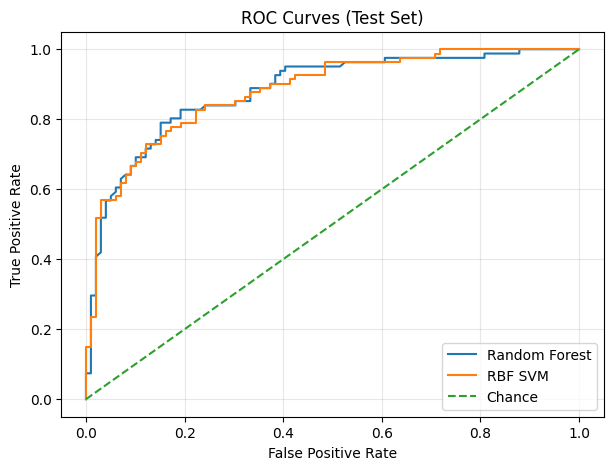

In [23]:
# ROC curves (both models in the same figure)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_score)

plt.figure(figsize=(7, 5))
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(svm_fpr, svm_tpr, label="RBF SVM")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **3. UNSUPERVISED LEARNING AND SEGMENTATION**

This chapter applies K-Means and DBSCAN to derive customer segments and compares their assumptions and practical usefulness.

Explained variance ratio (2 PCs): [0.265 0.161]


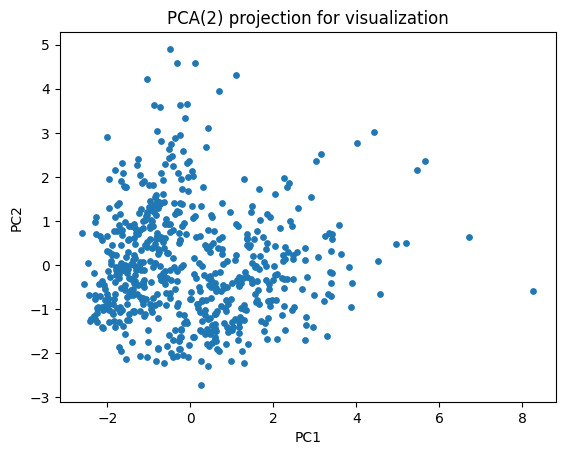

In [24]:
# Standardization and PCA for visualization
# PCA is primarily used to help visualize in two dimensions.

df1 = df.drop(columns=["Chanel"], errors="ignore")
scaler = StandardScaler()
Z = scaler.fit_transform(df1.values)

pca = PCA(n_components=2, random_state=42)
Z_pca2 = pca.fit_transform(Z)

print('Explained variance ratio (2 PCs):', np.round(pca.explained_variance_ratio_, 3))
plt.scatter(Z_pca2[:,0], Z_pca2[:,1], s=15)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA(2) projection for visualization')
plt.show()

#### **3.1 K-means Clustering**

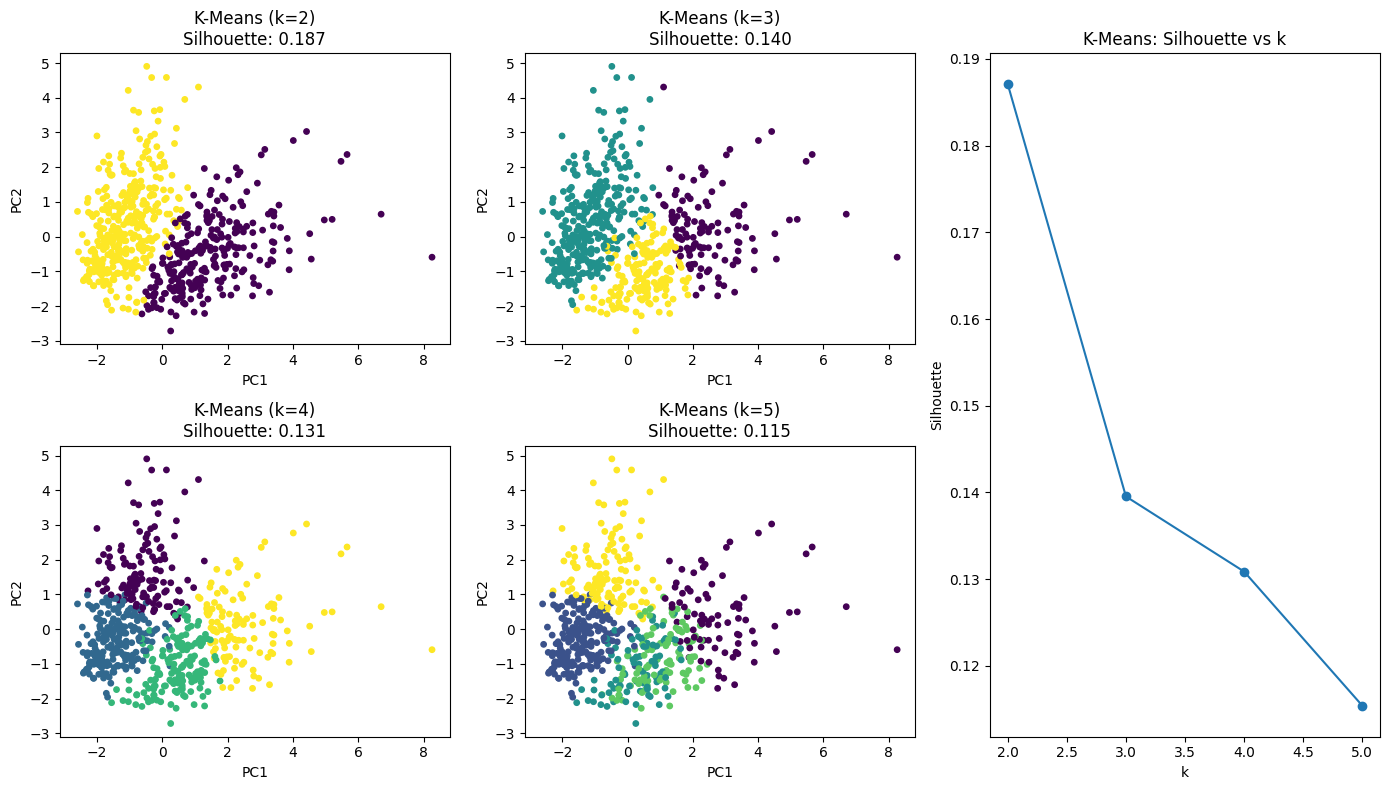

Best k by silhouette: 2


,k,Silhouette Score
0,2,0.187085
1,3,0.139539
2,4,0.130877
3,5,0.115413


In [25]:
# K-Means clustering
silhouette_scores = []
k_values = [2, 3, 4, 5]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3)

# Subplots de dispersión (2x2)
axes_scatter = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1])
]

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(Z)
    score = silhouette_score(Z, labels)
    silhouette_scores.append(score)

    ax = axes_scatter[i]
    ax.scatter(Z_pca2[:, 0], Z_pca2[:, 1],
               c=labels, cmap='viridis', s=15)
    ax.set_title(f'K-Means (k={k})\nSilhouette: {score:.3f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Gráfico de línea ocupando dos columnas
ax_line = fig.add_subplot(gs[:, 2])
ax_line.plot(list(k_values), silhouette_scores, marker='o')
ax_line.set_xlabel('k')
ax_line.set_ylabel('Silhouette')
ax_line.set_title('K-Means: Silhouette vs k')

plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(silhouette_scores))]
print('Best k by silhouette:', best_k)

# Display silhouette scores for each k
score_df = pd.DataFrame({
    'k': k_values,
    'Silhouette Score': silhouette_scores
})
display(score_df)

In [26]:
# Cluster profiling and naming (K-MEANS)
km_profile = df.assign(cluster=labels).groupby('cluster').agg(['mean','median']).round(2)
km_profile

Fresh             Milk          Grocery           Frozen          \
            mean  median     mean  median     mean  median     mean  median   
cluster                                                                       
0        3244.84  2855.0  2086.51  1567.0  5635.67  5417.0  2004.75  1749.0   
1        2107.77  1914.0  1898.72  1748.0  1524.07  1477.0  1307.04  1152.0   
2        1695.38  1352.0  1837.88  1311.0  2550.81  2545.0  1516.08  1351.0   
3        2139.35  1847.0  1927.48  1707.0  3632.64  3634.0   918.86   837.0   
4        5506.76  5193.5  2044.98  1813.5  2209.38  2129.5  1350.41  1204.0   

        Detergents_Paper         Delicatessen         Order_Frequency         \
                    mean  median         mean  median            mean median   
cluster                                                                        
0                2577.45  2430.0       846.10   672.0           12.02   11.9   
1                 667.38   653.0       927.19   782.0           11.73   11.8   
2                1169.71  1233.0      1346.18  1258.0           12.31   12.0   
3                1675.88  1722.0       565.66   523.0           13.09   13.1   
4                 948.96   948.0       847.73   724.0           11.30   11.2   

        Avg_Order_Value         Delivery_Distance        Channel         
                   mean  median              mean median    mean median  
cluster                                                                  
0               2974.92  2867.0             15.57  15.10    0.98    1.0  
1               1218.78  1237.0             18.07  17.70    0.00    0.0  
2               1382.16  1330.0             14.94  14.90    1.00    1.0  
3               1658.72  1623.0             20.76  20.90    1.00    1.0  
4               2630.52  2466.0             19.10  19.15    0.01    0.0

#### **3.2 DBSCAN Clustering**

In [27]:
#DBSCAN clustering

eps_grid = [1.5, 2.0]
min_samps = [4, 6, 8]
results = []

for eps in eps_grid:
    for ms in min_samps:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_DBSCAN = db.fit_predict(Z)
        n_clusters = len(set(labels_DBSCAN)) - (1 if -1 in labels_DBSCAN else 0)
        noise_frac = round(np.mean(labels_DBSCAN == -1), 3)
        # For valid silhouette, need at least 2 clusters and not all noise
        sil = np.nan
        if n_clusters >= 2 and noise_frac < 1.0:
            sil = round(silhouette_score(Z, labels_DBSCAN), 3)
        results.append((eps, ms, n_clusters, noise_frac, sil))

res_df = pd.DataFrame(results, columns=['eps','min_samples','n_clusters','noise_frac','silhouette'])
display(res_df)

,eps,min_samples,n_clusters,noise_frac,silhouette
0,1.5,4,8,0.570,-0.192
1,1.5,6,5,0.690,-0.170
2,1.5,8,3,0.813,-0.175
3,2.0,4,3,0.160,0.103
4,2.0,6,2,0.188,0.132
5,2.0,8,2,0.217,0.124


Chosen eps, min_samples: 2.0 6


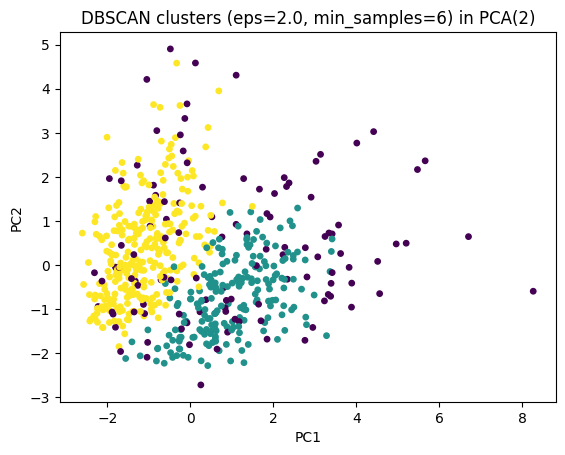

DBSCAN clusters: 2 ; noise fraction: 0.188 ; noise points: 113


In [28]:
# Pick a reasonable DBSCAN setting: most clusters with modest noise and decent silhouette if available
# Sorting Criteria: The code sorts the candidate results (cand) by two columns: silhouette (descending): Prioritizes higher silhouette scores, which indicate better-defined clusters. n_clusters (descending): Among results with equal silhouette scores, it prefers those with more clusters

cand = res_df.copy()
cand = cand.sort_values(by=['silhouette','n_clusters'], ascending=[False, False])
eps_best, ms_best = float(cand.iloc[0]['eps']), int(cand.iloc[0]['min_samples'])
print('Chosen eps, min_samples:', eps_best, ms_best)

db = DBSCAN(eps=eps_best, min_samples=ms_best)
db_labels = db.fit_predict(Z)

plt.scatter(Z_pca2[:,0], Z_pca2[:,1], c=db_labels, s=15)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(f'DBSCAN clusters (eps={eps_best}, min_samples={ms_best}) in PCA(2)')
plt.show()

db_n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise = np.mean(db_labels == -1)
noise_points = int(np.sum(db_labels == -1))
print('DBSCAN clusters:', db_n_clusters, '; noise fraction:', round(db_noise, 3), '; noise points:', noise_points)

In [29]:
# Cluster profiling and naming (DBSCAN)
db_profile = df.assign(cluster=db_labels).groupby('cluster').agg(['mean','median']).round(2)
db_profile

Fresh             Milk          Grocery           Frozen          \
            mean  median     mean  median     mean  median     mean  median   
cluster                                                                       
-1       3417.48  2564.0  2838.21  2359.0  3809.74  3261.0  1762.45  1450.0   
 0       2139.19  1848.0  1682.28  1434.0  3491.36  3335.0  1275.49  1103.0   
 1       3316.47  2822.0  1792.64  1671.5  1790.97  1693.5  1293.63  1158.0   

        Detergents_Paper         Delicatessen         Order_Frequency         \
                    mean  median         mean  median            mean median   
cluster                                                                        
-1               1742.66  1538.0      1434.93  1309.0           11.96   12.0   
 0               1605.33  1591.0       736.62   669.0           12.52   12.2   
 1                770.34   743.0       796.15   683.0           11.63   11.7   

        Avg_Order_Value         Delivery_Distance        Channel         
                   mean  median              mean median    mean median  
cluster                                                                  
-1              2480.93  2435.0             17.82  17.50    0.59    1.0  
 0              1757.51  1665.0             17.47  17.00    1.00    1.0  
 1              1689.47  1669.0             18.37  18.15    0.00    0.0